# BERT

In [1]:
!pip install -q transformers

from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

text = "I hate this product!"

result = classifier(text)[0]

binary_output = 1 if result['label'] == "POSITIVE" else 0

print("Text:", text)
print("Model Output:", result)
print("Binary:", binary_output)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: I hate this product!
Model Output: {'label': 'NEGATIVE', 'score': 0.9997503161430359}
Binary: 0


# GAN

2026-04-28 15:54:49.027611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777391689.295524      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777391689.374879      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777391690.030518      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777391690.030576      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777391690.030580      16 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-28 15:55:15.286556: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
(1, 784)


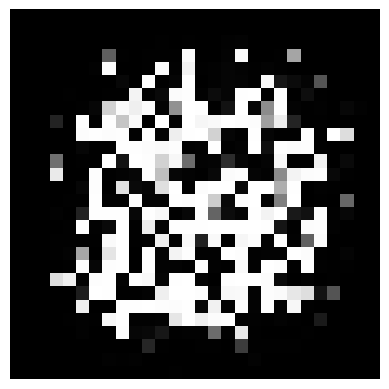

In [2]:
import tensorflow as tf
import numpy as np

# data
(x_train,_),_ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0

# generator
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=100),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

# discriminator
discriminator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=784),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile('adam','binary_crossentropy')

# GAN
discriminator.trainable = False
z = tf.keras.Input(shape=(100,))
gan = tf.keras.Model(z, discriminator(generator(z)))
gan.compile('adam','binary_crossentropy')

# training (minimal)
for _ in range(500):
    idx = np.random.randint(0, x_train.shape[0], 32)
    real = x_train[idx]

    noise = np.random.normal(0,1,(32,100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    discriminator.train_on_batch(real, np.ones((32,1)))
    discriminator.train_on_batch(fake, np.zeros((32,1)))

    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((32,1)))

# generate sample
img = generator.predict(np.random.normal(0,1,(1,100)))
print(img.shape)

import matplotlib.pyplot as plt

plt.imshow(img.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()